# Smart Microscopy v3

Adaptive overview -> target acquisition at two objectives, with
on-the-fly per-tile cellpose segmentation via the smart-analysis engine.

**Z handling:** z-wide everywhere; z-galvo never commanded (set it to
0 in LAS X before running for best accuracy -- preflight will warn).

All logic lives in `notebooks/workflow/`. Each cell here is a thin
wrapper. See `TARGET_ACQUISITION_DESIGN.md` for the full design.

Steps:

- **Cell 2** -- Config + LAS X connect (operator inputs).
- **Cell 3** -- Step 0: preflight (calibration, engine boot, register pipeline, telemetry).
- **Cell 4-5** -- Step 1: stage limits + strip + z-wide.
- **Cell 6-7** -- Step 2: read scan field + plot.
- **Cell 8-9** -- Step 3: focus map (AF at markers, fit z-wide plane).
- **Cell 10-11** -- Step 4: overview acquisition + engine analysis + pick filtering.
- **Cell 12-13** -- Step 5: target acquisition at high magnification.
- **Cell 14-15** -- Step 6: summary.json + results plot + cleanup.

In [1]:
import sys
from pathlib import Path

# Locate notebooks/workflow/ regardless of where Jupyter was launched.
# Covered launch modes:
#   - smart-microscopy/                            (repo root)
#   - .../navigator_expert/                        (parent of notebooks/)
#   - .../navigator_expert/notebooks/              (the notebooks dir itself)
#   - .../navigator_expert/<sibling-of-notebooks>/ (e.g., examples/, test/)
_HERE = Path.cwd()
for _c in [_HERE / "controller/vendor/leica/navigator_expert/notebooks",
           _HERE,
           _HERE / "notebooks",
           _HERE.parent / "notebooks"]:
    if (_c / "workflow" / "__init__.py").exists():
        sys.path.insert(0, str(_c.resolve()))
        break
else:
    raise RuntimeError(
        "Could not find notebooks/workflow/. Launch Jupyter from the "
        "smart-microscopy repo root, navigator_expert/, or "
        "navigator_expert/notebooks/."
    )

from LasxApi import PYLICamApiConnector as lasxApi
from workflow import Config

# --- LAS X connect (the notebook owns this; preflight receives an open client) ---
client = lasxApi.LasxApiClientPyModel
client.Connect("PythonClient")

# --- Operator inputs ---
# Stage XY limits come from boundary point markers placed in
# Navigator Expert (preferred); the physical envelope is read from
# stage.json. Z-wide limits come from stage.json. No coordinates
# typed by the operator here.
cfg = Config(
    # Slots and jobs
    source_slot=1,
    target_slot=2,
    acquisition_job="Overview",
    target_job="HiRes",
    af_job="AF Job",

    # Pick policy (top-N per overview tile)
    n_picks_per_tile=5,

    # Paths
    analysis_repo=Path(r"Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-analysis"),
    output_root=Path(r"Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-microscopy\controller\vendor\leica\navigator_expert\output\target_acquisition"),

    # Defaults made explicit
    feature="area",
    fov_bbox_margin=1.5,
    settle_after_objective_switch_s=3.0,
    smoke_test_pipeline=False,
)

print(f"Connected. Config built. Source slot {cfg.source_slot} -> target slot {cfg.target_slot}.")

Connected. Config built. Source slot 1 -> target slot 2.


In [2]:
from workflow import preflight

ctx = preflight(cfg, client)

[preflight] ok
  templates_dir : C:\Users\t.de\AppData\Roaming\Leica Microsystems\LAS X\MatrixScreener6\User_0\ScanningTemplates
  out_dir       : Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-microscopy\controller\vendor\leica\navigator_expert\output\target_acquisition\20260506_195244
  current_job   : Overview  (slot 1)
  source z-galvo: -0.000 um
  cellpose env  : NOT FOUND (ok for v0 stubs)


C:\Users\local_t.de2\Temp\ipykernel_30060\1725752324.py:3: UserWarning: Conda env 'SMART--target_acquisition--main' not found under any of: ['C:\\ProgramData\\MinicondaZMB\\envs\\SMART--target_acquisition--main', 'C:\\ProgramData\\MinicondaZMB\\envs\\SMART--target_acquisition--main']. v0 stubs do not need it; create it before wiring real cellpose into segment_tile.
  ctx = preflight(cfg, client)


## Step 1 -- Stage limits + template

Optionally place **point markers** in Navigator Expert at the corners of your
sample. The cell will derive XY stage limits from those markers (with
`cfg.limit_margin_um` padding), clamped to the physical envelope from
`stage.json` (any clamp is reported per axis).

If no markers are placed, the physical envelope is applied immediately
so any intermediate move stays bounded; XY narrowing is then deferred
to Step 2 (derived from the scan field, also clamped to the envelope).

The cell also strips the template and forces every job in the LRP to **z-wide**.

In [3]:
from workflow import prepare_template

prepare_template(ctx)

[step 1] Stage limits from 4 boundary marker(s) (envelope from stage.json):
  X: 18627 - 36414 um
  Y: 14668 - 32970 um
  z-wide: 0 - 25000 um (from stage.json)
[step 1] Template stripped and z-wide enforced on every job.


## Step 2 -- Scan field

Draw the scanning field in **Navigator Expert**, then run the next two cells.

[step 2] Synthesized 4 tiles from geometries (tile size 1160.0 um)
[step 2] Scan field: 1 region(s), 4 tile(s)
  Region 0: Overview  1x4  tile=1160.0 um
[step 2] Saved Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-microscopy\controller\vendor\leica\navigator_expert\output\target_acquisition\20260506_195244\overview_field.png


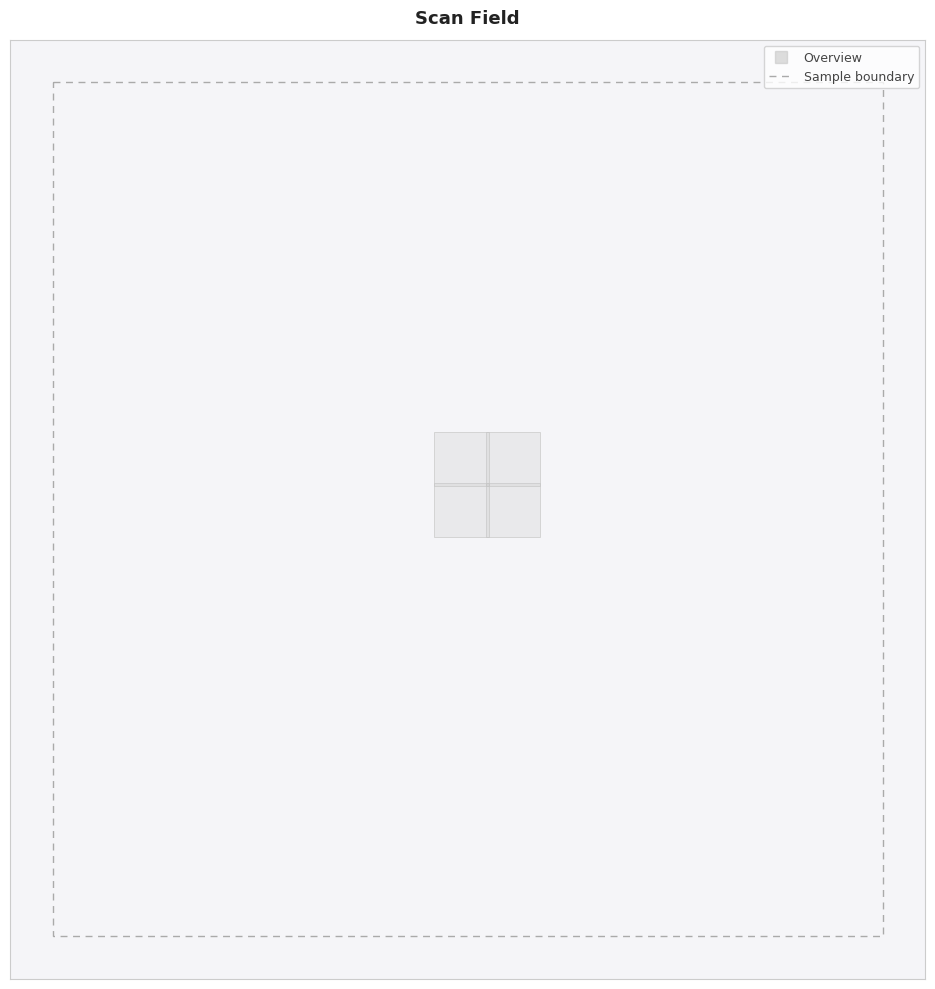

In [5]:
from workflow import read_scan_field, plot_scan_field

read_scan_field(ctx)
plot_scan_field(ctx)

## Step 3 -- Focus map

Place **focus markers** on the scan field in **Navigator Expert**, then run this cell.
Runs the AF job at each marker, reads back z-wide, fits a plane.

[step 3] Focus positions (2):
  1. x=27725.5  y=22792.5 um
  2. x=28446.5  y=23693.8 um

[1/2] x=27726  y=22792  z-wide=2663.00 um

[2/2] x=28447  y=23694  z-wide=2663.00 um

[step 3] Focus plane (z-wide):
  Z range:      0.00 um
  Tilt X:       +15.6723 deg
  Tilt Y:       -12.6506 deg
  Max residual: 0.000 um
[step 3] Saved Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-microscopy\controller\vendor\leica\navigator_expert\output\target_acquisition\20260506_195244\focus_map.png


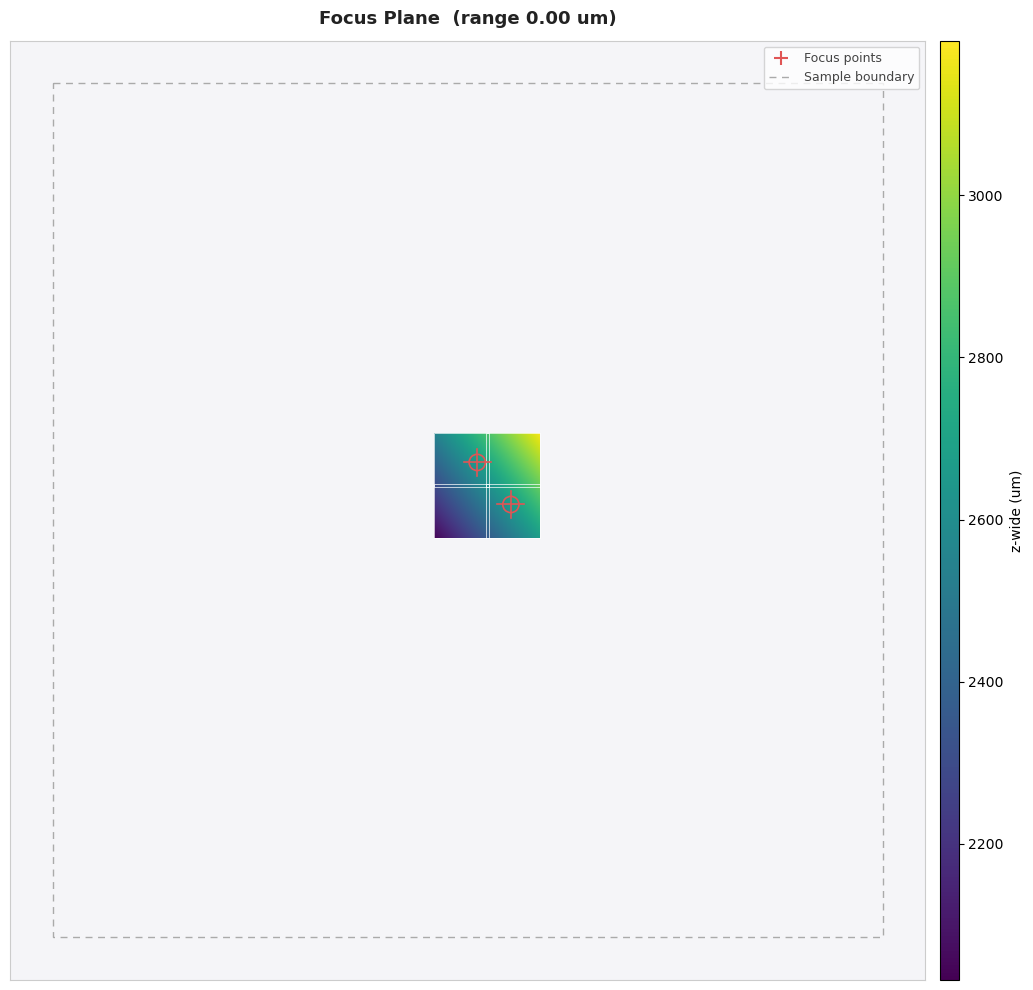

In [6]:
from workflow import build_focus_map

focus_map = build_focus_map(ctx)
focus_map.plot(ctx)

## Step 4 -- Overview + live analysis

Acquires every tile in snake order, submits each to the analysis engine
for cellpose segmentation + pick selection. Drains results, deduplicates
picks, and filters out-of-limits targets.

With v0 stubs the engine returns empty picks -- the acquisition loop
and drain still run end to end.

In [7]:
from workflow import run_overview_with_picks

picks = run_overview_with_picks(ctx, focus_map)

[step 4] 4 tiles in snake order
[1/4] R0 r0c0  x=27389 y=22740 z=2580.38  ok
[2/4] R0 r0c1  x=27389 y=23842 z=2333.04  ok
[3/4] R0 r0c2  x=28491 y=22740 z=2889.57  ok
[4/4] R0 r0c3  x=28491 y=23842 z=2642.22  ok

[step 4] Drain complete: 4 result(s), 0 engine failure(s), 0 tile acquire failure(s)
[step 4] Picks: 0 raw -> 0 dup, 0 out-xy, 0 out-z, 0 xlat-fail -> 0 final


### Simulator: inject synthetic picks

**Skip this cell on the real microscope.** Generates random picks from
the overview tile positions so Steps 5 and 6 can be tested on the
simulator where the v0 stubs return no picks.

Set `SIMULATE_PICKS = True` below to enable. The generated picks are
marked `simulated=True` on the Picks object and in `summary.json`.

In [8]:
SIMULATE_PICKS = True  # set True to test Steps 5-6 on the simulator

if not SIMULATE_PICKS:
    print("[simulator] SIMULATE_PICKS is False -- skipping synthetic pick injection.")
else:
    import random
    import numpy as np
    import navigator_expert.driver as drv
    from workflow import Pick, Picks
    from workflow.overview import _filter_out_of_limits

    random.seed(42)

    tile_positions = ctx.scan_field["tile_positions"]
    settings = drv.get_job_settings(ctx.client, cfg.acquisition_job)
    geo = drv.parse_tile_geometry(settings)
    pw, ph = float(geo["pixel_w_um"]), float(geo["pixel_h_um"])
    nx, ny = int(geo["pixels_x"]), int(geo["pixels_y"])
    img_to_stage = np.array(ctx.calibration["image_to_stage"])

    synthetic_picks = []
    for rid, region in tile_positions.items():
        for pos in region["positions"]:
            tile_x, tile_y = pos["x_um"], pos["y_um"]
            tile_z = float(focus_map.interpolate_zwide(tile_x, tile_y))
            n_cells = random.randint(2, 3)
            for label in range(1, n_cells + 1):
                col_px = nx / 2 + random.uniform(-nx * 0.3, nx * 0.3)
                row_px = ny / 2 + random.uniform(-ny * 0.3, ny * 0.3)
                offset_px = np.array([col_px - nx / 2, row_px - ny / 2])
                offset_um = offset_px * np.array([pw, ph])
                delta_xy = img_to_stage @ offset_um
                cell_x = tile_x + delta_xy[0]
                cell_y = tile_y + delta_xy[1]
                w_px = random.randint(20, 80)
                h_px = random.randint(20, 80)

                synthetic_picks.append(Pick(
                    pick_id=(str(rid), pos["row"], pos["col"], label),
                    tile_stage_xy_um=(tile_x, tile_y),
                    tile_zwide_um=tile_z,
                    source_pixel_size_um=(pw, ph),
                    source_image_size_px=(nx, ny),
                    centroid_col_row_px=(col_px, row_px),
                    bbox_px=(int(row_px - h_px / 2), int(col_px - w_px / 2),
                             int(row_px + h_px / 2), int(col_px + w_px / 2)),
                    bbox_um=(w_px * pw, h_px * ph),
                    area_px=w_px * h_px,
                    eccentricity=random.uniform(0.1, 0.8),
                    mean_intensity=random.uniform(5000, 20000),
                    cell_source_stage_xy_um=(cell_x, cell_y),
                ))

    n_raw = len(synthetic_picks)
    surviving, removed_xy, removed_z, removed_xlat = _filter_out_of_limits(
        synthetic_picks, ctx,
    )

    picks.items = surviving
    picks.n_picks_raw = n_raw
    picks.n_picks_out_of_limits_xy = len(removed_xy)
    picks.n_picks_out_of_limits_z = len(removed_z)
    picks.removed_picks.extend(removed_xy + removed_z + removed_xlat)
    picks.simulated = True

    print(f"[simulator] Injected {n_raw} synthetic picks, "
          f"{len(removed_xy)} out-xy, {len(removed_z)} out-z, "
          f"{len(removed_xlat)} xlat-fail -> "
          f"{len(surviving)} surviving (simulated=True)")

[simulator] Injected 10 synthetic picks, 0 out-xy, 0 out-z, 0 xlat-fail -> 10 surviving (simulated=True)


## Step 5 -- Target acquisition

Switches to the target objective and acquires each picked cell at high
magnification. With v0 stubs (0 picks), this step short-circuits.

In [9]:
from workflow import acquire_targets

records = acquire_targets(ctx, picks)

[step 5] 10 picks to acquire at slot 2
[1/10] pick=('0', 0, 1, 2)  src=(27132, 23688)  ok  zoom=1 tz=2329.3
[2/10] pick=('0', 0, 1, 1)  src=(27239, 23885)  ok  zoom=1 tz=2329.3
[3/10] pick=('0', 0, 0, 1)  src=(27546, 22409)  ok  zoom=3 tz=2576.7
[4/10] pick=('0', 0, 0, 2)  src=(27677, 23014)  ok  zoom=2 tz=2576.7
[5/10] pick=('0', 0, 2, 1)  src=(28172, 22500)  ok  zoom=2 tz=2885.9
[6/10] pick=('0', 0, 3, 1)  src=(28349, 23896)  ok  zoom=1 tz=2638.5
[7/10] pick=('0', 0, 2, 2)  src=(28419, 22983)  ok  zoom=1 tz=2885.9
[8/10] pick=('0', 0, 2, 3)  src=(28576, 23070)  ok  zoom=2 tz=2885.9
[9/10] pick=('0', 0, 3, 3)  src=(28582, 23748)  ok  zoom=1 tz=2638.5
[10/10] pick=('0', 0, 3, 2)  src=(28678, 23549)  ok  zoom=2 tz=2638.5

[step 5] Done: 10/10 targets acquired


## Step 6 -- Outputs + cleanup

Writes `summary.json`, plots results in the overview frame, optionally
restores the source objective, and shuts down the engine.

[step 6] Saved Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-microscopy\controller\vendor\leica\navigator_expert\output\target_acquisition\20260506_195244\summary.json
[step 6] Saved Z:\zmbstaff\10374\Protocols_Notes\thom\notes\repositories\smart-microscopy\controller\vendor\leica\navigator_expert\output\target_acquisition\20260506_195244\results.png


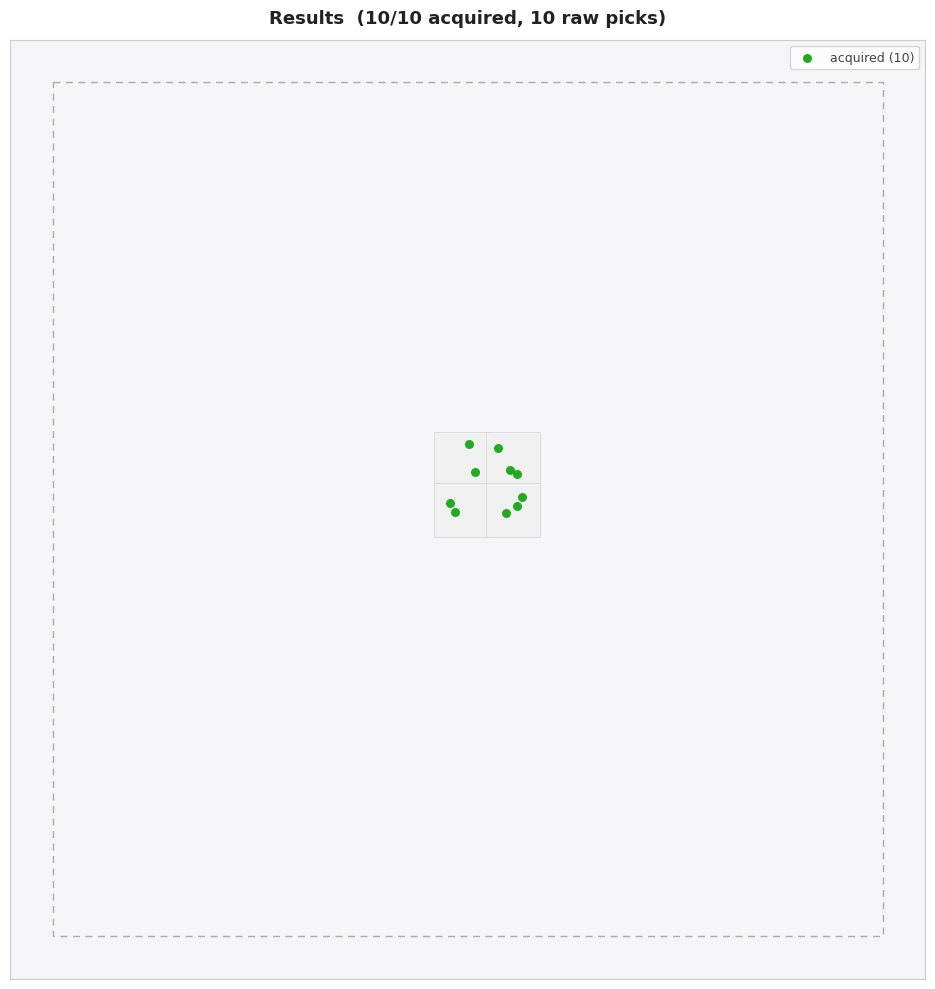

get_jobs: attempt 1/3 timed out
get_jobs: attempt 2/3 timed out


[step 6] Restored source objective (slot 1).
[step 6] Shutdown complete.


In [10]:
from workflow import write_summary, plot_results, finish

write_summary(ctx, focus_map, picks, records)
plot_results(ctx, focus_map, picks, records)
finish(ctx)